<a href="https://colab.research.google.com/github/kelvin-yg98/Python-Individual-Classwork/blob/main/Kelvin_Individual_Classwork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

,Order_ID,Date,Region,Sales_Channel,Customer_Segment,Product,Units_Sold,Unit_Price,Discount,Revenue
0,1001,2026-01-01,West,Online,Consumer,Tablet,9,250,NaN,2250.0
1,1002,2026-01-02,north,Retail,consumer,Monitor,4,600,0.00,2400.0
2,1003,2026-01-03,East,ONLINE,nan,Tablet,1,600,0.15,510.0
3,1004,2026-01-04,north,Online,consumer,Phone,4,350,NaN,1400.0
4,1005,2026-01-05,north,ONLINE,nan,Tablet,1,600,0.15,510.0
5,1006,2026-01-06,South,Online,nan,Tablet,5,350,0.05,1662.5
6,1007,2026-01-07,East,Retail,Small Business,Tablet,4,250,0.05,950.0
7,1008,2026-01-08,East,online,nan,Monitor,8,900,NaN,7200.0
8,1009,2026-01-09,East,Online,consumer,Monitor,8,900,0.15,6120.0
9,1010,2026-01-10,north,ONLINE,nan,Tablet,7,250,0.00,1750.0


Shape: (86, 10)

Missing Values:
Order_ID             0
Date                 0
Region               0
Sales_Channel        0
Customer_Segment     0
Product              0
Units_Sold           0
Unit_Price           0
Discount            19
Revenue              0
dtype: int64

Duplicated Rows: 0


/tmp/ipykernel_4230/807892388.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Product', y='Revenue', palette='Set3')


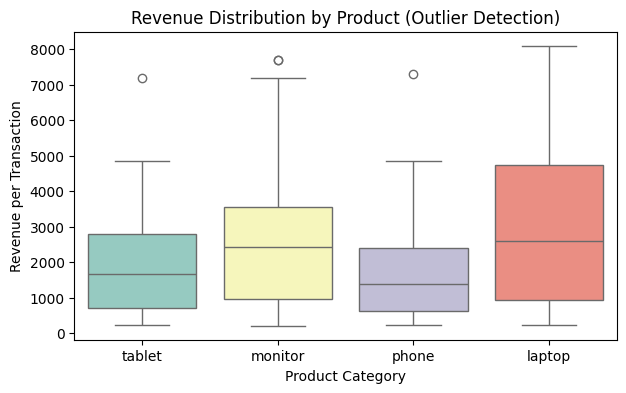

Product
monitor    83152.5
laptop     52232.5
tablet     44047.5
phone      32292.5
Name: Revenue, dtype: float64


/tmp/ipykernel_4230/807892388.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prod_rev.index, y=prod_rev.values, palette='Blues_r', legend=False)


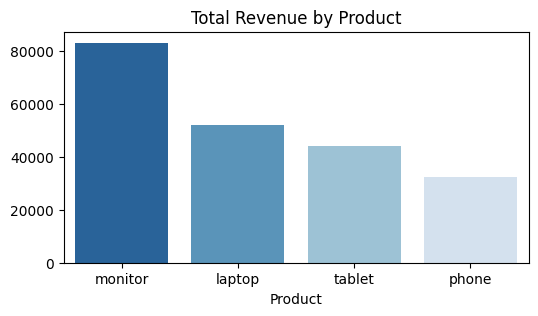

Units Sold by Segment:
 Customer_Segment
consumer          199
unknown            80
small business     68
corporate          53
Name: Units_Sold, dtype: int64


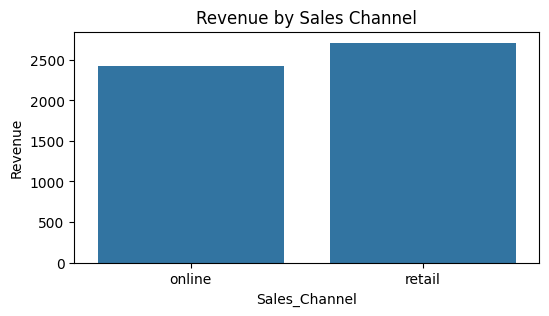

/tmp/ipykernel_4230/807892388.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=reg_rev.values, y=reg_rev.index, palette='viridis', legend=False)


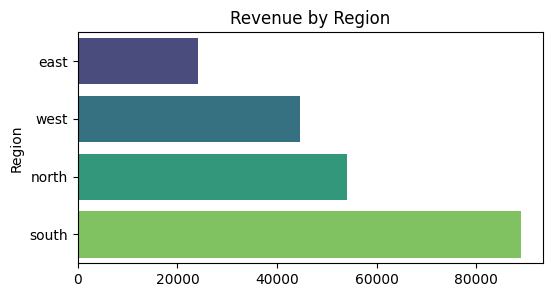

Correlation:
           Discount   Revenue
Discount  1.000000 -0.070321
Revenue  -0.070321  1.000000


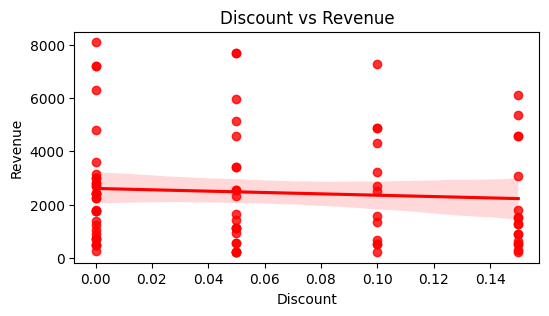

/tmp/ipykernel_4230/807892388.py:86: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=prod_pop.index, y=prod_pop.values, palette='rocket', legend=False)


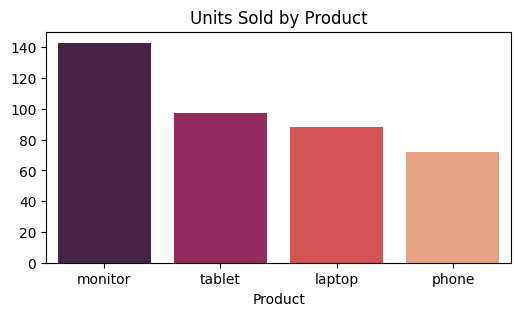

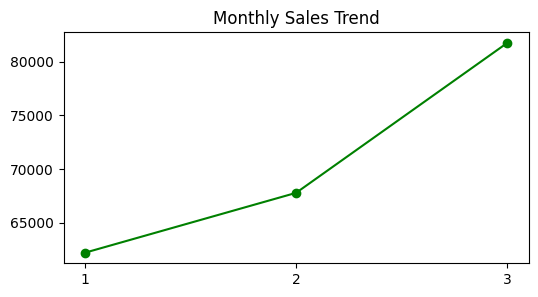

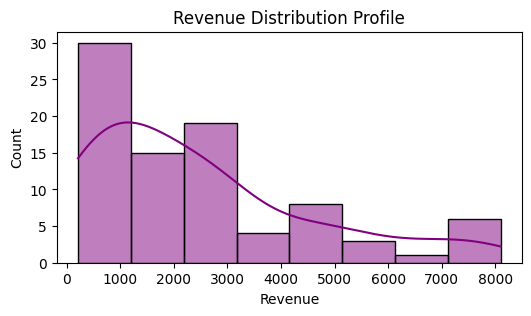

Total Profit by Product:
Product
monitor    77870.375
laptop     50758.625
tablet     41398.375
phone      30229.625
Name: Profit, dtype: float64

Profit Margin by Region:
Region
north    0.957163
west     0.945230
south    0.944294
east     0.927338
Name: Profit_Margin, dtype: float64

Correlation between Discount and Profit: -0.1368


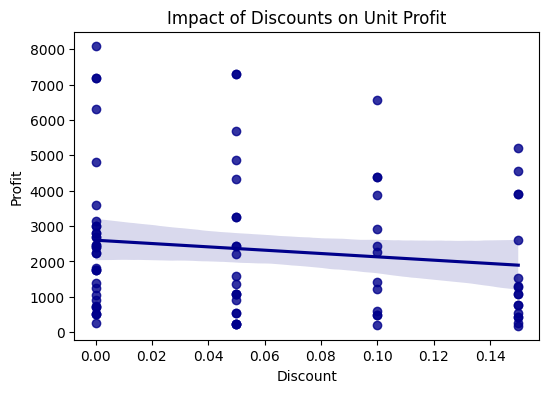

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
rows = 86

# Creating the precise columns from my original sales spreadsheet
mock_data = {
    'Order_ID': range(1001, 1001 + rows),
    'Date': pd.date_range(start='2026-01-01', periods=rows, freq='D'),
    'Region': np.random.choice(['North', 'South', 'East', 'West', 'north', 'south'], size=rows),
    'Sales_Channel': np.random.choice(['Online', 'Retail', 'online', 'ONLINE'], size=rows),
    'Customer_Segment': np.random.choice(['Consumer', 'Corporate', 'Small Business', 'consumer', np.nan], size=rows),
    'Product': np.random.choice(['Laptop', 'Phone', 'Tablet', 'Monitor'], size=rows),
    'Units_Sold': np.random.randint(1, 10, size=rows),
    'Unit_Price': np.random.choice([900, 600, 350, 250], size=rows),
    'Discount': np.random.choice([0.0, 0.05, 0.1, 0.15, np.nan], size=rows),
}

df = pd.DataFrame(mock_data)
# Calculate baseline revenue mapping standard equations
df['Revenue'] = (df['Units_Sold'] * df['Unit_Price'] * (1 - df['Discount'].fillna(0))).round(2)

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
display(df)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

print(f"Shape: {df.shape}")
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicated Rows:", df.duplicated().sum())

# DATA CLEANING
# Standardize all lowercase string categories
for col in ['Region', 'Sales_Channel', 'Customer_Segment', 'Product']:
    df[col] = df[col].astype(str).str.lower().str.strip()

df['Customer_Segment'] = df['Customer_Segment'].replace('nan', 'unknown').fillna('unknown')
df['Discount'] = df['Discount'].fillna(0)

# Outlier detection visualization
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='Product', y='Revenue', hue='Product', palette='Set3', legend=False)
plt.title("Revenue Distribution by Product (Outlier Detection)")
plt.xlabel("Product Category")
plt.ylabel("Revenue per Transaction")
plt.show()

# REVENUE ANALYSIS
prod_rev = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False)
print(prod_rev)
plt.figure(figsize=(6, 3))
sns.barplot(x=prod_rev.index, y=prod_rev.values, palette='Blues_r', legend=False)
plt.title("Total Revenue by Product")
plt.show()

# CUSTOMER BEHAVIOUR
seg_units = df.groupby('Customer_Segment')['Units_Sold'].sum().sort_values(ascending=False)
print("Units Sold by Segment:\n", seg_units)
plt.figure(figsize=(6, 3))
sns.barplot(data=df, x='Sales_Channel', y='Revenue', errorbar=None)
plt.title("Revenue by Sales Channel")
plt.show()

# REVENUE BY REGION
reg_rev = df.groupby("Region")["Revenue"].sum().sort_values()
plt.figure(figsize=(6, 3))
sns.barplot(x=reg_rev.values, y=reg_rev.index, palette='viridis', legend=False)
plt.title("Revenue by Region")
plt.show()

# DISCOUNT IMPACT
print("Correlation:\n", df[['Discount', 'Revenue']].corr())
plt.figure(figsize=(6, 3))
sns.regplot(data=df, x='Discount', y='Revenue', color='red')
plt.title("Discount vs Revenue")
plt.show()

# PRODUCT POPULARITY
prod_pop = df.groupby('Product')['Units_Sold'].sum().sort_values(ascending=False)
plt.figure(figsize=(6, 3))
sns.barplot(x=prod_pop.index, y=prod_pop.values, palette='rocket', legend=False)
plt.title("Units Sold by Product")
plt.show()

# MONTHLY SALES TREND
df["Date"] = pd.to_datetime(df["Date"])
monthly = df.groupby(df["Date"].dt.month)["Revenue"].sum()
plt.figure(figsize=(6, 3))
plt.plot(monthly.index, monthly.values, marker='o', color='g')
plt.title("Monthly Sales Trend")
plt.xticks(monthly.index)
plt.show()

# REVENUE DISTRIBUTION
plt.figure(figsize=(6, 3))
sns.histplot(df["Revenue"], kde=True, color="purple")
plt.title("Revenue Distribution Profile")
plt.show()

# ADVANCED ANALYSIS
# Create the Profit column based on the formula
df['Profit'] = df['Revenue'] * (1 - df['Discount'])

# 1. Which product has the highest total profit?
product_profit = df.groupby('Product')['Profit'].sum().sort_values(ascending=False)
print("Total Profit by Product:")
print(product_profit)

# 2. Which region has the best profit margin?
# Profit Margin = Total Profit / Total Revenue
region_metrics = df.groupby('Region').agg({'Profit': 'sum', 'Revenue': 'sum'})
region_metrics['Profit_Margin'] = region_metrics['Profit'] / region_metrics['Revenue']
region_margin = region_metrics['Profit_Margin'].sort_values(ascending=False)
print("\nProfit Margin by Region:")
print(region_margin)

# 3. Does discount increase or reduce profit?
discount_profit_corr = df[['Discount', 'Profit']].corr().iloc[0, 1]
print(f"\nCorrelation between Discount and Profit: {discount_profit_corr:.4f}")

# Visualization to check the trend
plt.figure(figsize=(6, 4))
sns.regplot(data=df, x='Discount', y='Profit', color='darkblue')
plt.title("Impact of Discounts on Unit Profit")
plt.show()